# DAT 402 PROJECT 2
## Team Members: Dain Lee & Manaswi Kondapally


## Introduction

In the fast-paced world of delivery services, predicting accurate delivery times is crucial for optimizing operations, improving customer satisfaction, and managing resources effectively. This project focuses on building a model to predict delivery times based on several key factors, including weather conditions, traffic levels, distance, and vehicle type. By accurately forecasting delivery times, businesses can better manage customer expectations, improve service quality, and streamline their logistics processes.

### Research Questions

The core objective of this project is to explore and answer the following research questions:

1. How do various factors such as weather, traffic levels, and vehicle types affect the total delivery time?
2. Can we build a model that accurately predicts delivery time based on historical data and relevant features?
3. Which features have the most significant impact on predicting delivery time, and how can we leverage this insight to optimize delivery operations?
4. How do different machine learning models - Random Forest & XGBoost - compare in terms of predicting delivery times?

### Dataset Overview

The dataset used in this study contains detailed information about delivery orders. Each record in the dataset represents a unique delivery and includes the following features:

- **Order_ID**: Unique identifier for each delivery order.
- **Distance_km**: The distance (in kilometers) between the restaurant and the delivery address.
- **Weather**: The weather conditions at the time of the delivery (e.g., clear, rainy, foggy).
- **Traffic_Level**: The level of traffic encountered during the delivery (e.g., light, moderate, heavy).
- **Time_of_Day**: The time when the delivery occurred (e.g., morning, afternoon, evening).
- **Vehicle_Type**: Type of vehicle used for the delivery (e.g., motorcycle, car, bike).
- **Preparation_Time_min**: The time taken by the restaurant to prepare the order (in minutes).
- **Courier_Experience_yrs**: The number of years of experience of the courier delivering the order.
- **Delivery_Time_min**: The target variable representing the total time taken for the delivery (in minutes).

The dataset provides a rich set of features that could influence delivery times, making it suitable for building predictive models. By analyzing this dataset, we aim to uncover key patterns that can inform strategies to improve delivery efficiency and accuracy.


### 1. Importing the Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

### 2. Loading the Dataset

In [ ]:
df = pd.read_csv('Food_Delivery_Times.csv')

# Checking the first few rows
print(df.head())

   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  


### 3. Data Preprocessing: Converting Data Types
In this step, we ensure that the dataset is properly formatted for analysis. The `Order_ID` column, which represents unique delivery identifiers, is converted to a string type to prevent any issues related to numerical representations. Additionally, we verify that the `Delivery_Time_min` column, which contains the total delivery time in minutes, is of a numeric type. Any non-numeric values in this column are coerced into NaN to ensure the data is clean and ready for further processing. The transformation is then validated by displaying the first few rows of these columns.

In [ ]:
df['Order_ID'] = df['Order_ID'].astype(str)

df['Delivery_Time_min'] = pd.to_numeric(df['Delivery_Time_min'], errors='coerce')

print(df[['Order_ID', 'Delivery_Time_min']].head())


  Order_ID  Delivery_Time_min
0      522                 43
1      738                 84
2      741                 59
3      661                 37
4      412                 68


### 4. Handling Missing Values
This step addresses missing values in the dataset to ensure the integrity of the data before analysis. First, the number of missing values in each column is checked. Since the `Delivery_Time_min` column is the target variable, rows with missing values in this column are dropped. For categorical columns like `Weather`, `Traffic_Level`, and `Vehicle_Type`, missing values are filled with the placeholder value *'Unknown'*. For numerical columns such as `Distance_km`, `Preparation_Time_min`, and `Courier_Experience_yrs`, missing values are filled with the median value of each respective column to maintain the dataset's statistical consistency. The changes are then verified by displaying the updated dataset.

In [ ]:
print(df.isnull().sum())

df = df.dropna(subset=['Delivery_Time_min'])

df['Weather'].fillna('Unknown', inplace=True)
df['Traffic_Level'].fillna('Unknown', inplace=True)
df['Vehicle_Type'].fillna('Unknown', inplace=True)


df['Distance_km'].fillna(df['Distance_km'].median(), inplace=True)
df['Preparation_Time_min'].fillna(df['Preparation_Time_min'].median(), inplace=True)
df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median(), inplace=True)

print(df.head())


Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64
   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  

<ipython-input-31-63f3f7d5703b>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weather'].fillna('Unknown', inplace=True)
<ipython-input-31-63f3f7d5703b>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

### 5. Exploratory Data Analysis (EDA)

EDA is performed to understand the distribution of key features and identify relationships between variables, helping to inform the model-building process.

#### 5.1 Distribution of Delivery Time

The histogram reveals a Gaussian distribution, with the majority of delivery times clustered between 40 and 60 minutes, indicating that most deliveries fall within this time range.

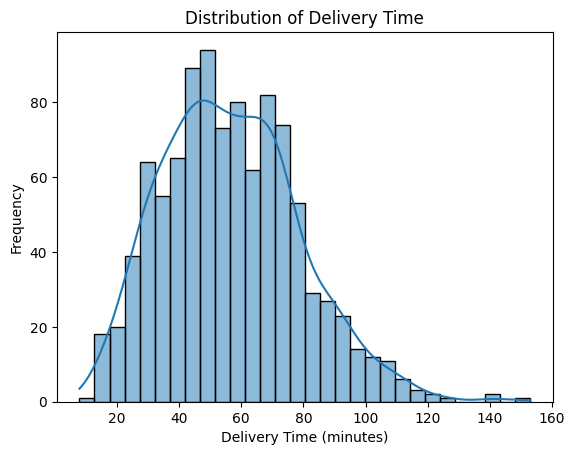

In [ ]:
sns.histplot(df['Delivery_Time_min'], bins=30, kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()


#### 5.2 Impact of Weather & Traffic on Delivery Time

The boxplot shows that snowy weather is associated with the highest delivery times, while clear days typically result in the lowest delivery times. This suggests that adverse weather conditions, particularly snow, significantly increase delivery time. While the seconf boxplot gives an insight on how there is a clear proportional relationship between traffic levels and delivery time.

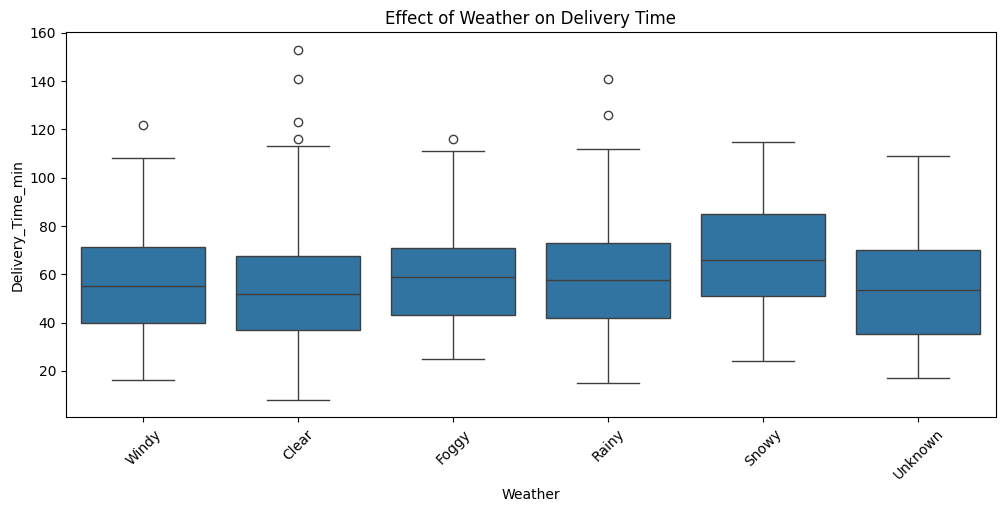

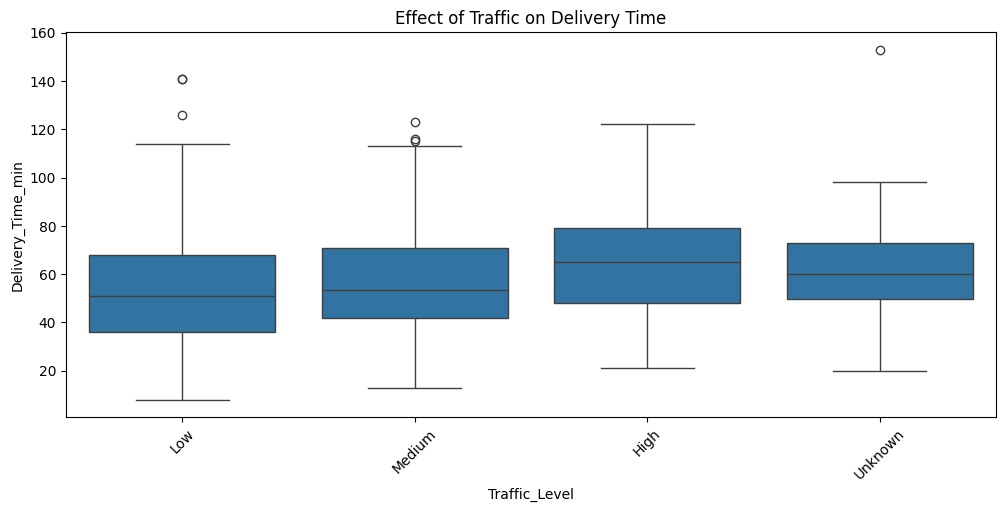

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='Weather', y='Delivery_Time_min', data=df)
plt.xticks(rotation=45)
plt.title('Effect of Weather on Delivery Time')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df)
plt.xticks(rotation=45)
plt.title('Effect of Traffic on Delivery Time')
plt.show()

#### 5.3 Relationship between Distance and Delivery Time

The scatterplot reveals a linear relationship between distance and delivery which is also very intuitive.

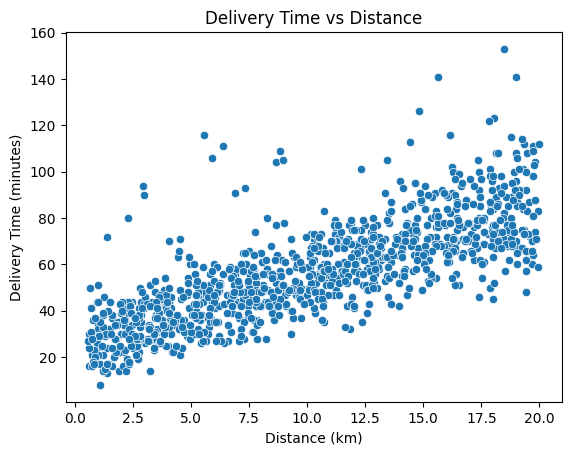

In [ ]:
sns.scatterplot(x=df['Distance_km'], y=df['Delivery_Time_min'])
plt.title('Delivery Time vs Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (minutes)')
plt.show()

#### 5.4 Correlation Matrix

As seen earlier, delivery time has a strong positive correlation with distance. Although the experience level of the courier has a low correlation with delivery time, it is important to note that, during model training, this feature proves to be more influential in predicting delivery times than the correlation suggests.

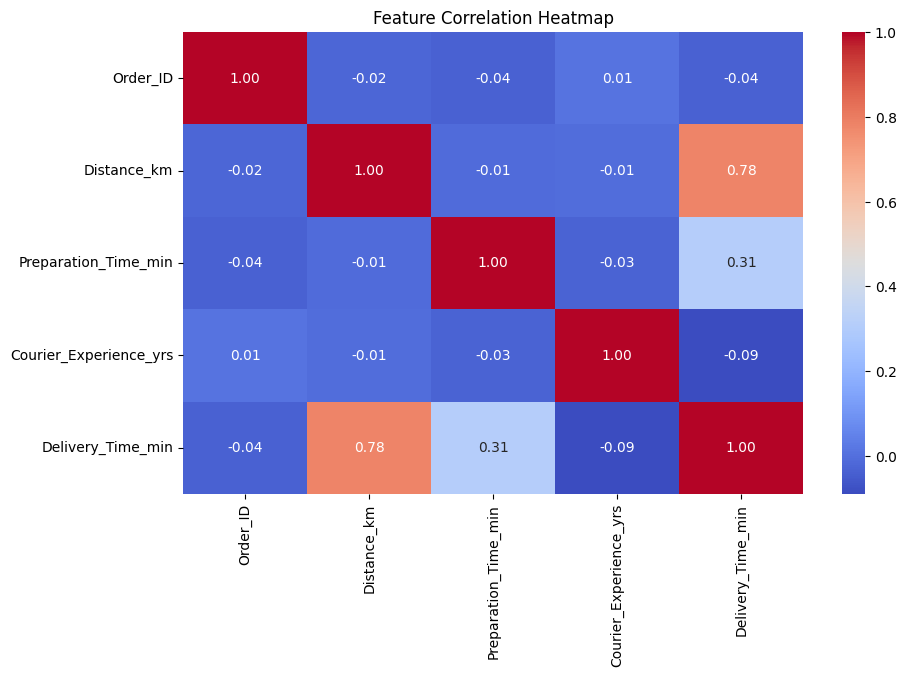

In [ ]:
plt.figure(figsize=(10, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

### 6. Unsupervised Learning: K-Means Clustering

The K-means clustering results, visualized using PCA, show the separation of the dataset into three distinct clusters. The clusters are formed based on the numerical features `Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, and `Delivery_Time_min`. The plot reveals clear groupings of delivery orders, which could indicate different types of delivery scenarios based on the cluster.

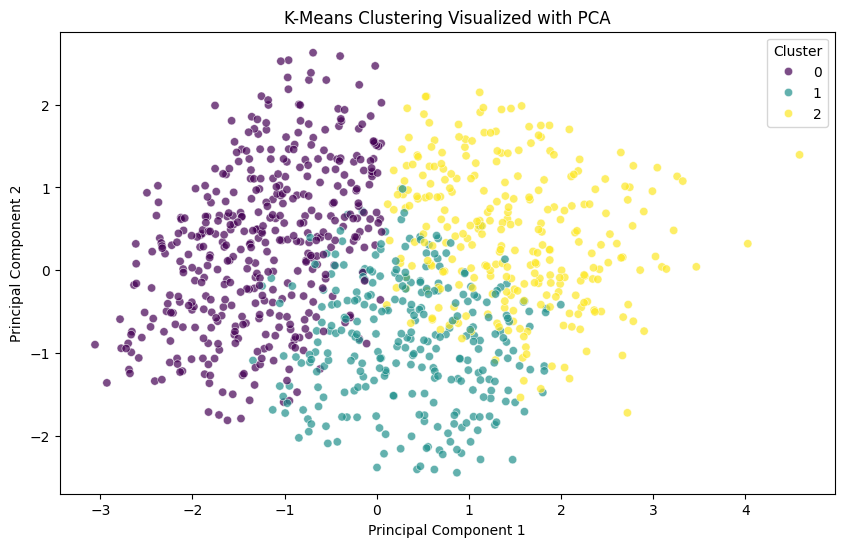

In [ ]:
features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Setting the number of clusters
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)


pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']


plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', palette='viridis', data=pca_df, alpha=0.7)
plt.title('K-Means Clustering Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


### 7. Supervised Learning

In this section, we apply supervised learning techniques to predict delivery times based on various features. The dataset is split into training and testing sets, and multiple regression models, including Random Forest and XGBoost, are trained to predict the delivery time. The models are evaluated based on performance metrics such as Mean Squared Error (MSE) and R-squared (R²), providing insight into their accuracy and effectiveness in predicting delivery times.

In [ ]:


y = df['Delivery_Time_min']


features = ['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
            'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs']
X = df[features]
X = pd.get_dummies(X, columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
num_features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print(X_train.head())


     Distance_km  Preparation_Time_min  Courier_Experience_yrs  Weather_Foggy  \
29      1.389200             -0.980721                0.820833          False   
535    -1.391140              0.126852               -0.557994          False   
695    -1.200658             -0.011595                1.510246          False   
557    -0.452710              1.372871                0.476126          False   
836    -0.957750             -1.257614               -0.557994          False   

     Weather_Rainy  Weather_Snowy  Weather_Unknown  Weather_Windy  \
29           False          False            False          False   
535          False          False            False          False   
695          False          False            False          False   
557           True          False            False          False   
836           True          False            False          False   

     Traffic_Level_Low  Traffic_Level_Medium  Traffic_Level_Unknown  \
29               False     

#### 7.1 Random Forest Regressor

The Random Forest Regressor model was trained with 100 estimators and evaluated on the test set. The model MSE of 106.02 and an R² value of 0.76. These results indicate that the model performs reasonably well, capturing a substantial portion of the variance in delivery times, with a good balance between accuracy and complexity.

In [ ]:
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random Forest Regressor -- MSE: {rf_mse:.2f}, R²: {rf_r2:.2f}")


Random Forest Regressor -- MSE: 106.02, R²: 0.76


#### 7.2 XGBoost Regressor

The XGBoost Regressor model was trained with 100 estimators as well, a learning rate of 0.1, and the objective set to `reg:squarederror`. Given the relatively smaller size of the dataset, the gradient boosting approach used by XGBoost is suitable for improving performance. The model achieved a MSE of 105.70 and an R² value of 0.76. These results indicate that the XGBoost model performs similarly to the RF model, providing good predictive accuracy for delivery times while leveraging the power of gradient boosting.

In [ ]:
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)


xgb_pred = xgb_model.predict(X_test)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)
print(f"XGBoost Regressor -- MSE: {xgb_mse:.2f}, R²: {xgb_r2:.2f}")


XGBoost Regressor -- MSE: 105.70, R²: 0.76


#### 7.3 Testing Set Predictions

In this section, predictions for the test set are generated using both the trained models.

In [ ]:
df_test = df.loc[X_test.index].copy()

df_test['rf_pred'] = rf_model.predict(X_test)
df_test['xgb_pred'] = xgb_model.predict(X_test)


#### 7.4 Actual vs Predicted Delivery Times

The scatterplots show the comparison between actual and predicted delivery times for both the Random Forest (blue) and XGBoost (green) models. In both plots, the predicted values (on the y-axis) are plotted against the actual delivery times (on the x-axis). The red dashed line represents the best-fit line, where predictions perfectly match the actual values.

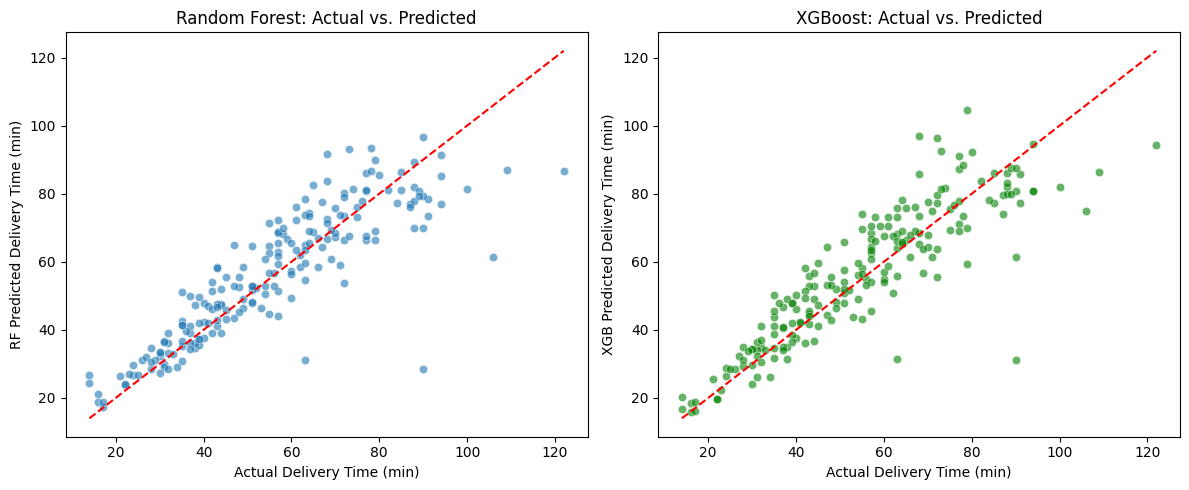

In [ ]:
plt.figure(figsize=(12, 5))

# Random Forest
plt.subplot(1, 2, 1)
sns.scatterplot(x=df_test['Delivery_Time_min'], y=df_test['rf_pred'], alpha=0.6)
plt.plot([df_test['Delivery_Time_min'].min(), df_test['Delivery_Time_min'].max()],
         [df_test['Delivery_Time_min'].min(), df_test['Delivery_Time_min'].max()], 'r--')
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("RF Predicted Delivery Time (min)")
plt.title("Random Forest: Actual vs. Predicted")

# XGBoost
plt.subplot(1, 2, 2)
sns.scatterplot(x=df_test['Delivery_Time_min'], y=df_test['xgb_pred'], alpha=0.6, color='green')
plt.plot([df_test['Delivery_Time_min'].min(), df_test['Delivery_Time_min'].max()],
         [df_test['Delivery_Time_min'].min(), df_test['Delivery_Time_min'].max()], 'r--')
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("XGB Predicted Delivery Time (min)")
plt.title("XGBoost: Actual vs. Predicted")

plt.tight_layout()
plt.show()


#### 7.5 Residuals Distribution

The histograms show the distribution of residuals (the difference between actual and predicted delivery times). In both cases, the residuals exhibit a Gaussian distribution, with a peak around 0, indicating that most of the prediction errors are relatively small and close to zero. This suggests that both models perform well in predicting delivery times, with minor deviations. However, there are also some outliers with residuals reaching up to 60 minutes, indicating occasional larger prediction errors for certain instances. The dashed vertical line at 0 further emphasizes the central tendency of the residuals.

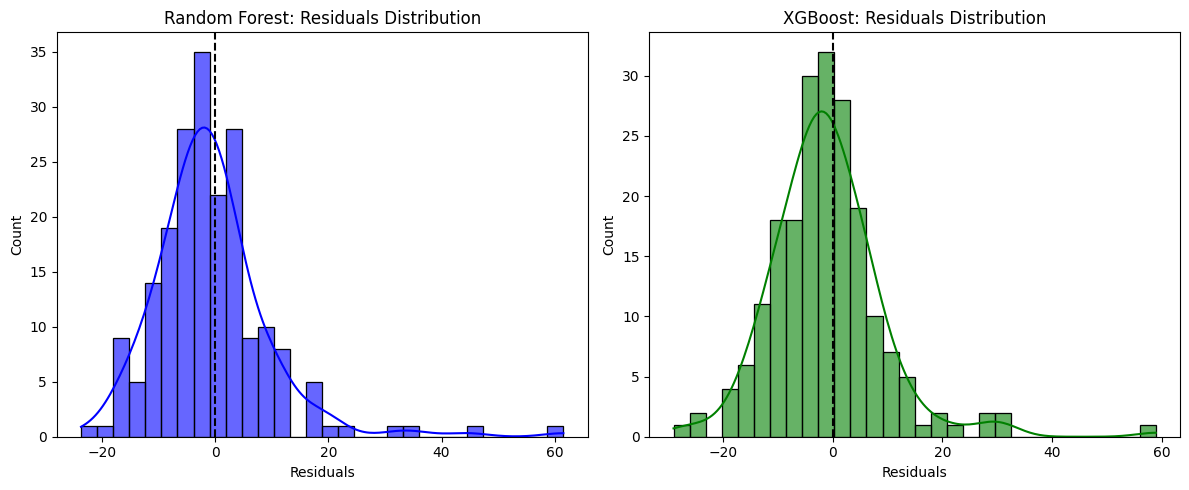

In [ ]:
plt.figure(figsize=(12, 5))

# Calculate residuals
df_test['rf_residuals'] = df_test['Delivery_Time_min'] - df_test['rf_pred']
df_test['xgb_residuals'] = df_test['Delivery_Time_min'] - df_test['xgb_pred']

# Histogram of Residuals
plt.subplot(1, 2, 1)
sns.histplot(df_test['rf_residuals'], bins=30, kde=True, color='blue', alpha=0.6)
plt.axvline(0, color='black', linestyle='dashed')
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.title("Random Forest: Residuals Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df_test['xgb_residuals'], bins=30, kde=True, color='green', alpha=0.6)
plt.axvline(0, color='black', linestyle='dashed')
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.title("XGBoost: Residuals Distribution")

plt.tight_layout()
plt.show()


#### 7.6 Error by Distance

The boxplots show the distribution of residuals (prediction errors) binned by distance (in kilometers). As the distance increases, the residuals tend to increase as well, suggesting that both models tend to make larger errors for longer deliveries. This pattern can be attributed to several external factors that are not considered in the models, such as road quality or the number of traffic lights etc. These variables, which can affect delivery times but are not part of the dataset, may cause the models to make less accurate predictions as the distance grows.

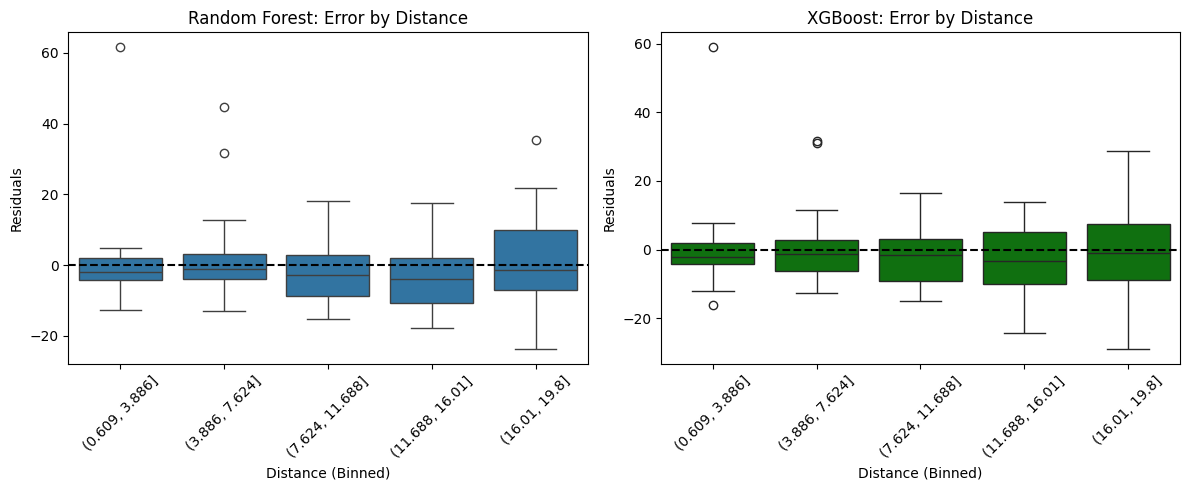

In [ ]:
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
sns.boxplot(x=pd.qcut(df_test['Distance_km'], q=5), y=df_test['rf_residuals'])
plt.axhline(0, color='black', linestyle='dashed')
plt.xticks(rotation=45)
plt.xlabel("Distance (Binned)")
plt.ylabel("Residuals")
plt.title("Random Forest: Error by Distance")


plt.subplot(1, 2, 2)
sns.boxplot(x=pd.qcut(df_test['Distance_km'], q=5), y=df_test['xgb_residuals'], color='green')
plt.axhline(0, color='black', linestyle='dashed')
plt.xticks(rotation=45)
plt.xlabel("Distance (Binned)")
plt.ylabel("Residuals")
plt.title("XGBoost: Error by Distance")

plt.tight_layout()
plt.show()


#### 7.7 Feature Importance

##### **Random Forest Regressor**

The bar plot displays the feature importance for the Random Forest model, which helps identify the most influential factors in predicting delivery time. The most significant feature is clearly Distance, followed by Preparation Time, which has a substantial impact on delivery time as well. Courier Experience also contributes notably to the model's predictions, as experienced couriers tend to have more efficient deliveries. Traffic Level and Weather, while important, have a relatively smaller impact compared to the other features.

<ipython-input-26-b5f672e002bb>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_feature_importance, palette='viridis')


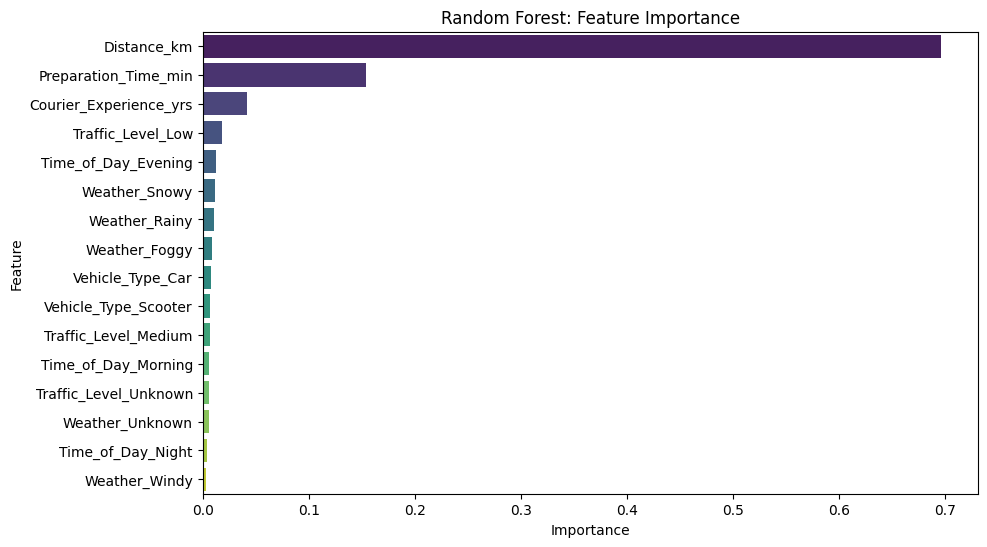

In [ ]:
rf_importance = rf_model.feature_importances_

rf_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importance
})

rf_feature_importance = rf_feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importance, palette='viridis')
plt.title("Random Forest: Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


##### **XGBoost Regressor**

Unlike the Random Forest model, Traffic Level and Weather emerge as more significant features in this model, indicating that these factors have a stronger influence on delivery times. Courier Experience, while still important, plays a comparatively smaller role in the XGBoost model.

<ipython-input-38-4d65f3a9a19e>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance, palette='plasma')


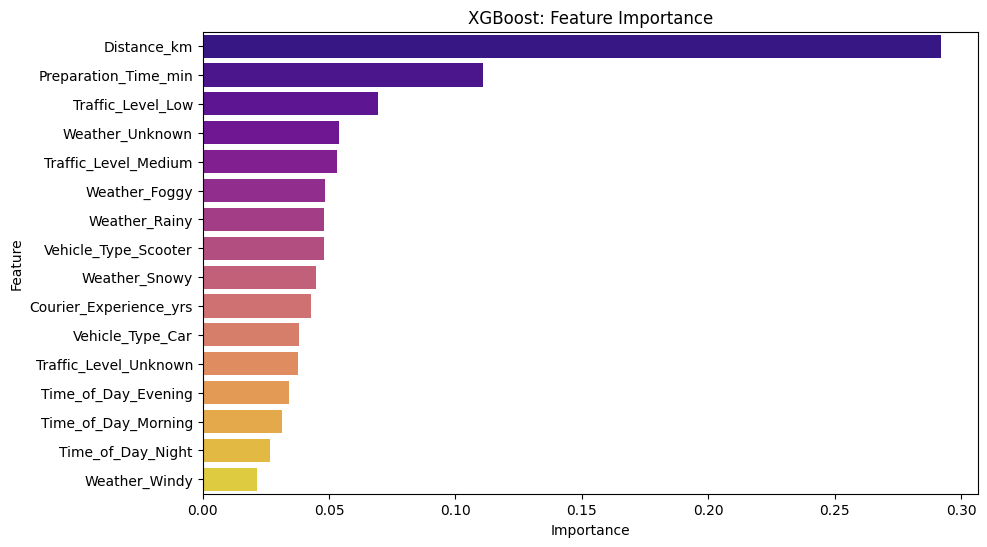

In [ ]:
xgb_importance = xgb_model.feature_importances_

xgb_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_importance
})

xgb_feature_importance = xgb_feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance, palette='plasma')
plt.title("XGBoost: Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Conclusion

In this project, we analyzed a dataset to predict delivery times based on various factors such as weather, traffic, and courier experience. Through exploratory data analysis (EDA), feature engineering, and both unsupervised and supervised machine learning techniques, we built models to estimate delivery times effectively. Random Forest and XGBoost models were used to make predictions, and we observed that factors like distance, preparation time, and traffic played significant roles in the predictions. The models performed well, with R² values of 0.76 for both Random Forest and XGBoost, providing useful insights into the delivery process.